In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df["result"] = df["math score"].apply(lambda x: 1 if x >= 50 else 0)

In [4]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
result                         0
dtype: int64

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [6]:
df_encoded.head()

,math score,reading score,writing score,result,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,1,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,1,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,1,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,0,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,1,True,False,True,False,False,False,False,False,True,False,True,True


In [7]:
X = df_encoded.drop("result", axis=1)
Y = df_encoded["result"]

print(X.shape)

(1000, 15)


In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [9]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [12]:
Y_pred = knn.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred)

print("KNN Accuracy =", accuracy)

KNN Accuracy = 0.895


In [13]:
accuracy_list = []

k_values = range(1, 30)

for k in k_values:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    
    Y_pred = knn.predict(X_test)
    
    acc = accuracy_score(Y_test, Y_pred)
    
    accuracy_list.append(acc)

In [14]:
for i in range(len(accuracy_list)):
    print("K =", i+1, "Accuracy =", accuracy_list[i])

K = 1 Accuracy = 0.905
K = 2 Accuracy = 0.895
K = 3 Accuracy = 0.895
K = 4 Accuracy = 0.895
K = 5 Accuracy = 0.895
K = 6 Accuracy = 0.895
K = 7 Accuracy = 0.89
K = 8 Accuracy = 0.895
K = 9 Accuracy = 0.89
K = 10 Accuracy = 0.895
K = 11 Accuracy = 0.89
K = 12 Accuracy = 0.89
K = 13 Accuracy = 0.88
K = 14 Accuracy = 0.885
K = 15 Accuracy = 0.885
K = 16 Accuracy = 0.885
K = 17 Accuracy = 0.88
K = 18 Accuracy = 0.88
K = 19 Accuracy = 0.875
K = 20 Accuracy = 0.87
K = 21 Accuracy = 0.87
K = 22 Accuracy = 0.87
K = 23 Accuracy = 0.87
K = 24 Accuracy = 0.87
K = 25 Accuracy = 0.875
K = 26 Accuracy = 0.875
K = 27 Accuracy = 0.875
K = 28 Accuracy = 0.88
K = 29 Accuracy = 0.88


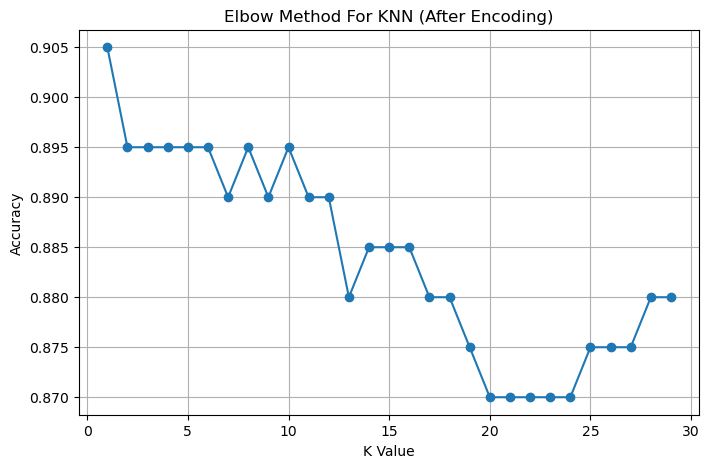

In [15]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracy_list, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Elbow Method For KNN (After Encoding)")

plt.grid(True)
plt.show()